In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [109]:
import black_litterman_recommender as blr
import importlib

importlib.reload(blr)

<module 'black_litterman_recommender' from '/home/neo_chavez/personal/Markowitz_Optimization/black_litterman_recommender.py'>

In [110]:
import utils as ut
import data_prep
import markowitz_analysis as ma
import markowitz_plots as mp

In [111]:
df = pd.read_csv('cleaned_ratings.csv', index_col=0)

In [112]:
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")

In [113]:
util = blr.stocktwits_to_sentiment_matrix(
    df,
    user_col = "user_id",
    asset_col = "symbol_list",
    sentiment_col = "sentiment",
    bullish_values = (1, "bullish", "Bullish", "BULLISH"),
    bearish_values = (-1,"bearish", "Bearish", "BEARISH"),
)

In [114]:
util = util[returns_matrix.columns.intersection(util.columns)]

In [115]:
U, V, _ = blr.als_explicit(util, 8, lam=0.1, max_iter=50, tol=1e-4, seed=42)

In [116]:
investor_id = 5
recs, scores = blr.recommend_from_als(util, U, V, investor_id, top_n=500)

In [117]:
scores = blr.investor_recommender_scores_als(
    M=util,
    U=U,
    V=V,
    investor_id=investor_id,
    exclude_observed=True,
)

In [118]:
returns_train = returns_matrix[returns_matrix.index < "2024-01-01"]
returns_train = returns_train[returns_train.index >= "2022-01-01"]
prior_mu = returns_train[util.iloc[:,recs].columns]
assets = pd.Index(util.iloc[:, recs].columns).astype(str)

R = returns_train.reindex(columns=assets)

# keep only assets with complete data for this window
R = R.dropna(axis=1, how="any")

assets = R.columns

prior_mu = R.mean().to_numpy().reshape(-1, 1)   # (n, 1)
sigma_prior = R.cov().to_numpy()                # (n, n)

tau=0.01
# P must also be built on these same assets, in this exact order

In [119]:
from sklearn.covariance import LedoitWolf
sigma_prior = LedoitWolf().fit(R).covariance_

In [ ]:
P, Q, Omega, view_table = blr.build_relative_views_from_scores(
    scores=scores[assets],
    tickers=assets,
    sigma_prior=sigma_prior,
    tau=tau,
    n_views=100,
    view_return_scale=0.04 / 252,
    min_confidence = 0.35,
    max_confidence = 0.90,
)

In [121]:
posterior_mu, posterior_sigma = blr.black_litterman_posterior(
        prior_mu=prior_mu,
        sigma_prior=sigma_prior,
        P=P,
        Q=Q,
        Omega=Omega,
        tau=tau,
    )

In [122]:
N = len(assets)
min_vol_max_sharpe_bl, _, weights_bl = ut.min_vol_max_sharpe(
    posterior_mu,
    posterior_sigma,
    N,
    R,
    risk_free_rate=0.04 / 252,
)

In [123]:
# choose one portfolio weights vector
w_bl = weights_bl[1]   # [0] min-vol, [1] max-Sharpe

last_R_date = R.index.max()

# future slice from the full returns matrix
future_returns = returns_matrix.loc[returns_matrix.index > last_R_date]

# portfolio returns on dates after the last date in R
bl_ret_future = (
    future_returns.reindex(columns=w_bl.index) * w_bl
).sum(axis=1)

bl_ret_future.head()

Date
2024-01-02    0.007741
2024-01-03    0.011600
2024-01-04    0.000474
2024-01-05    0.001732
2024-01-08    0.023347
dtype: float64

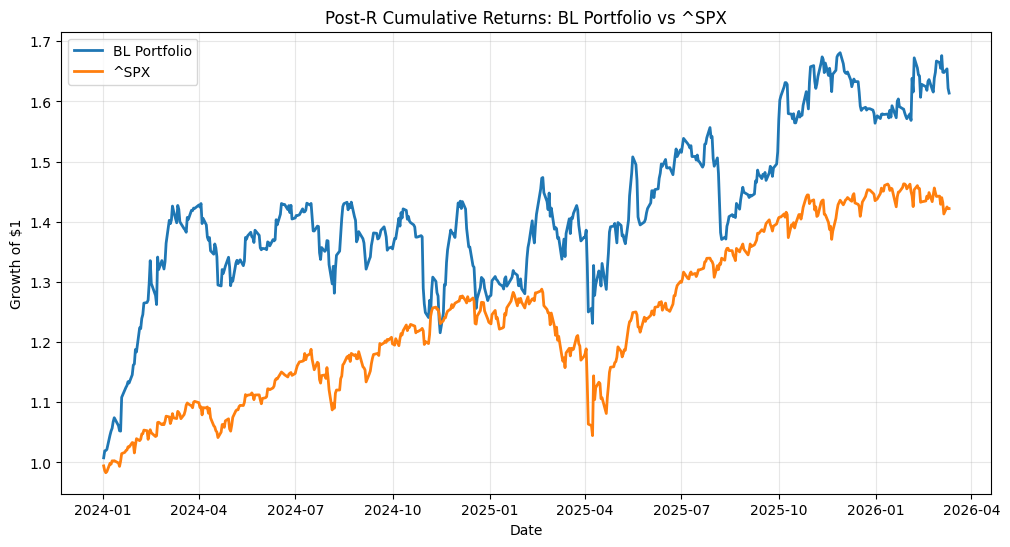

In [124]:
benchmark_ticker = "^SPX"   # or "^GSPC"

bench_ret_future = future_returns[benchmark_ticker]
if isinstance(bench_ret_future, pd.DataFrame):
    bench_ret_future = bench_ret_future.iloc[:, 0]

plot_df_future = pd.concat(
    [
        bl_ret_future.rename("BL Portfolio"),
        bench_ret_future.rename(benchmark_ticker),
    ],
    axis=1,
).dropna()

cum_df_future = (1 + plot_df_future).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_df_future.index, cum_df_future["BL Portfolio"], label="BL Portfolio", linewidth=2)
plt.plot(cum_df_future.index, cum_df_future[benchmark_ticker], label=benchmark_ticker, linewidth=2)
plt.title(f"Post-R Cumulative Returns: BL Portfolio vs {benchmark_ticker}")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [129]:
means = []
seeds = [42, 67, 69, 1337, 420]
for seed in seeds:
    util_train, util_test = blr.make_holdout(util, test_frac=0.2, min_pos=2, seed=seed)
    als_ndcg = blr.mean_ndcg_from_scores(
        M_train=util_train,
        M_test=util_test,
        U=U,
        V=V,
        k=10,
    )

    pop_ndcg = blr.mean_ndcg_from_popularity(
        M_train=util_train,
        M_test=util_test,
        k=10,
    )
    means.append((als_ndcg, pop_ndcg))
    print("ALS mean NDCG@10:", als_ndcg)
    print("Popularity mean NDCG@10:", pop_ndcg)
    print("Lift over popularity:", als_ndcg - pop_ndcg)

ALS mean NDCG@10: 0.1290154585615914
Popularity mean NDCG@10: 0.0007985643482433277
Lift over popularity: 0.1282168942133481
ALS mean NDCG@10: 0.12862196972768417
Popularity mean NDCG@10: 0.0008802338148246388
Lift over popularity: 0.12774173591285953
ALS mean NDCG@10: 0.12897048635803163
Popularity mean NDCG@10: 0.0007350584682578716
Lift over popularity: 0.12823542788977377
ALS mean NDCG@10: 0.12921266881499358
Popularity mean NDCG@10: 0.0006855733644881388
Lift over popularity: 0.12852709545050545
ALS mean NDCG@10: 0.12902991130444633
Popularity mean NDCG@10: 0.0007753179179787167
Lift over popularity: 0.1282545933864676


In [ ]:
# ---------------------------------------------------
# 1) Build the utility matrix from your StockTwits data
# # ---------------------------------------------------
# util = blr.stocktwits_to_sentiment_matrix(
#     df,
#     user_col="user_id",
#     asset_col="symbol_list",
#     sentiment_col="sentiment",
#     bullish_values=(1, "bullish", "Bullish", "BULLISH"),
#     bearish_values=(-1, "bearish", "Bearish", "BEARISH"),
# )

# ---------------------------------------------------
# 2) Make train/test split for recommendation evaluation
# ---------------------------------------------------

# # ---------------------------------------------------
# # 3) Fit ALS on TRAIN only
# # ---------------------------------------------------
# U, V, rmse_hist = blr.als_explicit(
#     M=util_train,
#     d=8,
#     lam=0.1,
#     max_iter=50,
#     tol=1e-4,
#     seed=42,
# )

# # ---------------------------------------------------
# # 4) Get recommendation scores for one investor
# # ---------------------------------------------------
# investor_id = util_train.index[0]

# scores = blr.investor_recommender_scores_als(
#     M=util_train,
#     U=U,
#     V=V,
#     investor_id=investor_id,
#     exclude_observed=True,
# )

# print("Top scores:")
# print(scores.head(10))

# # # ---------------------------------------------------
# # # 5) NDCG@10 for that investor
# # # ---------------------------------------------------
# # ndcg_10 = blr.ndcg_from_scores(
# #     M_train=util_train,
# #     M_test=util_test,
# #     U=U,
# #     V=V,
# #     investor_id=investor_id,
# #     k=10,
# # )

# # print("NDCG@10:", ndcg_10)

# # ---------------------------------------------------
# # 6) Mean NDCG@10 across all investors
# # ---------------------------------------------------
# mean_ndcg_10 = blr.mean_ndcg_from_scores(
#     M_train=util_train,
#     M_test=util_test,
#     U=U,
#     V=V,
#     k=100,
# )

# print("Mean NDCG@100:", mean_ndcg_10)